<a href="https://colab.research.google.com/github/introvet7/ksvd/blob/main/%D0%9A%D0%A0_%D0%9A%D0%A1%D0%92%D0%94.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Кияшко Ілля ФІТ 3-8
КСВД підсумкова контрольна робота

## Імпорт необхідних бібліотек
Перед початком виконання завдань імпортуємо всі бібліотеки, які знадобляться для роботи з даними та візуалізації.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
import plotly.express as px
from vega_datasets import data

## Завдання 1
Аналіз датасету Global YouTube Statistics 2023.


,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


Розмір датасету: (995, 28)

Кількість пропусків до обробки: 1616
Кількість дублікатів: 0

Пропуски в числових колонках після обробки: 3980

Кількість унікальних країн: 50


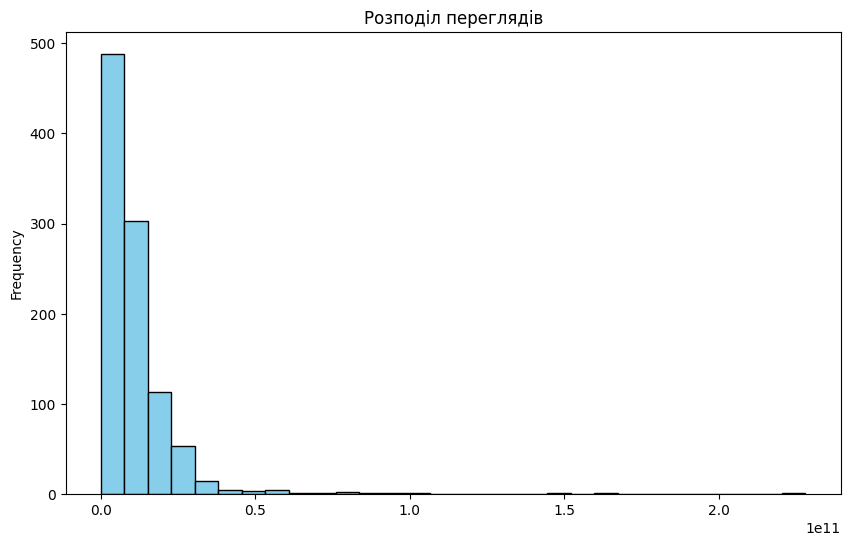


Максимальна кількість переглядів: 228000000000.0
Мінімальна кількість переглядів: 0.0
Середня кількість переглядів: 11039537052.03819

Країна з найбільшою кількістю завантажених відео: India

Канал з найбільшою кількістю завантажень: ABP NEWS
Канал з найменшою кількістю завантажень: Music


In [12]:
try:
    # читаємо дані з файлу
    df_yt = pd.read_csv('Global YouTube Statistics.csv', encoding='latin-1')
    display(df_yt.head())

    # глянемо на розміри та чи є пусті клітинки
    print("Розмір датасету:", df_yt.shape)
    print("\nКількість пропусків до обробки:", df_yt.isna().sum().sum())
    print("Кількість дублікатів:", df_yt.duplicated().sum())

    # заповнюємо пусті країни на Unknown
    if 'Country' in df_yt.columns:
        df_yt['Country'] = df_yt['Country'].fillna('Unknown')

    # заповнюємо пусті цифри середнім значенням
    for col in df_yt.columns:
        if df_yt[col].isna().any():
            try:
                df_yt[col] = pd.to_numeric(df_yt[col], errors='coerce')
                if df_yt[col].notna().any():
                    df_yt[col] = df_yt[col].fillna(df_yt[col].mean())
            except:
                pass

    # перевірка після обробки
    print("\nПропуски в числових колонках після обробки:", df_yt.select_dtypes(include=[np.number]).isna().sum().sum())

    # скільки у нас країн у списку
    print("\nКількість унікальних країн:", df_yt['Country'].nunique())

    # малюємо гістограму переглядів
    plt.figure(figsize=(10, 6))
    df_yt['video views'].plot(kind='hist', bins=30, color='skyblue', edgecolor='black')
    plt.title('Розподіл переглядів')
    plt.show()

    # статистика по переглядах
    print("\nМаксимальна кількість переглядів:", df_yt['video views'].max())
    print("Мінімальна кількість переглядів:", df_yt['video views'].min())
    print("Середня кількість переглядів:", df_yt['video views'].mean())

    # де найбільше завантажують відео
    top_c = df_yt.groupby('Country')['uploads'].sum().idxmax()
    print("\nКраїна з найбільшою кількістю завантажених відео:", top_c)

    # канали з макс та мін кількістю відео
    mx_idx = df_yt['uploads'].idxmax()
    mn_idx = df_yt['uploads'].idxmin()
    print(f"\nКанал з найбільшою кількістю завантажень: {df_yt.loc[mx_idx, 'Youtuber']}")
    print(f"Канал з найменшою кількістю завантажень: {df_yt.loc[mn_idx, 'Youtuber']}")
except FileNotFoundError:
    print("Помилка: Файл не знайдено, перевір назву.")

## Завдання 2
Аналіз архіву Customer Shopping Trends Dataset.
Робота з файлом shopping_trends.csv та візуалізація за допомогою бібліотеки seaborn.

Розмір таблиці: (3900, 19)

Типи стовпців:
 Customer ID                   int64
Age                           int64
Gender                       object
Item Purchased               object
Category                     object
Purchase Amount (USD)         int64
Location                     object
Size                         object
Color                        object
Season                       object
Review Rating               float64
Subscription Status          object
Payment Method               object
Shipping Type                object
Discount Applied             object
Promo Code Used              object
Previous Purchases            int64
Preferred Payment Method     object
Frequency of Purchases       object
dtype: object

Оновлені назви стовпців: ['customer_id', 'age', 'gender', 'item_purchased', 'category', 'purchase_amount_(usd)', 'location', 'size', 'color', 'season', 'review_rating', 'subscription_status', 'payment_method', 'shipping_type', 'discount_applied', 'promo_cod

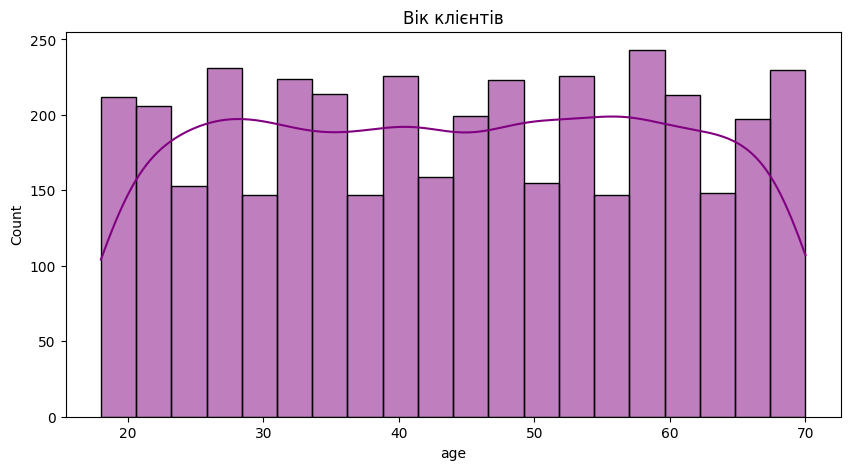

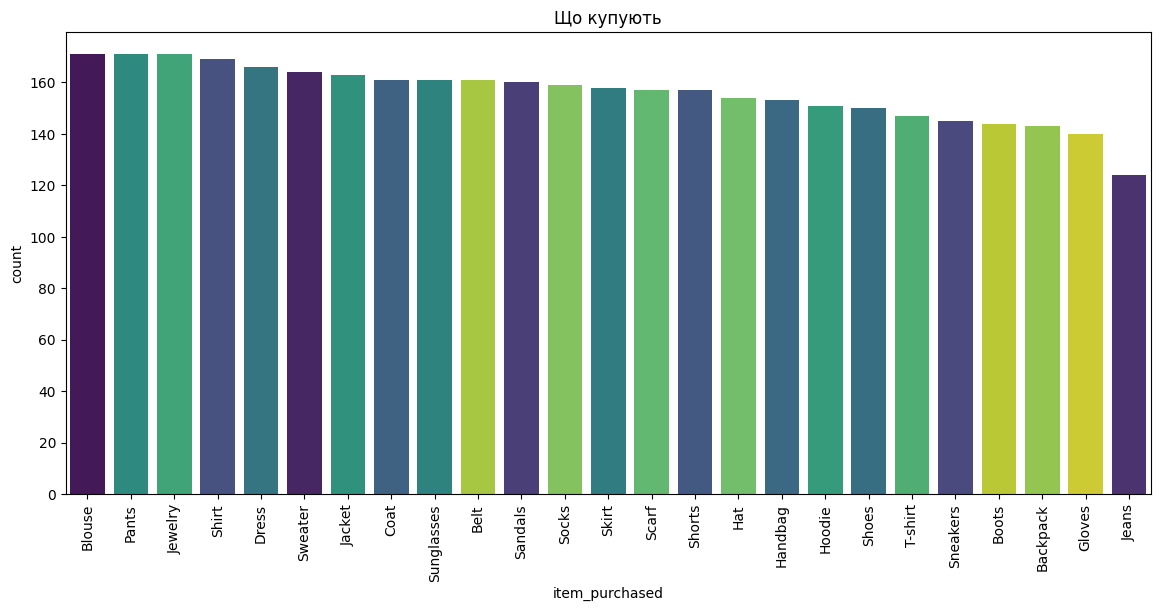

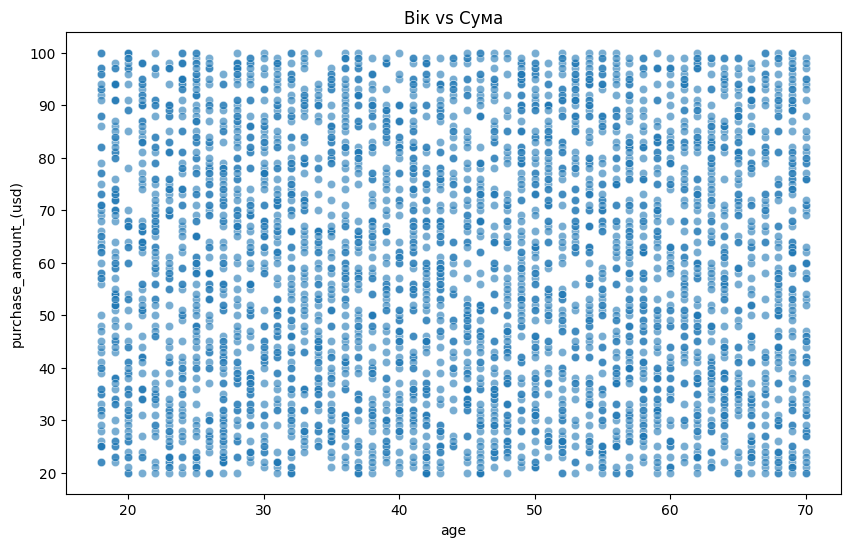

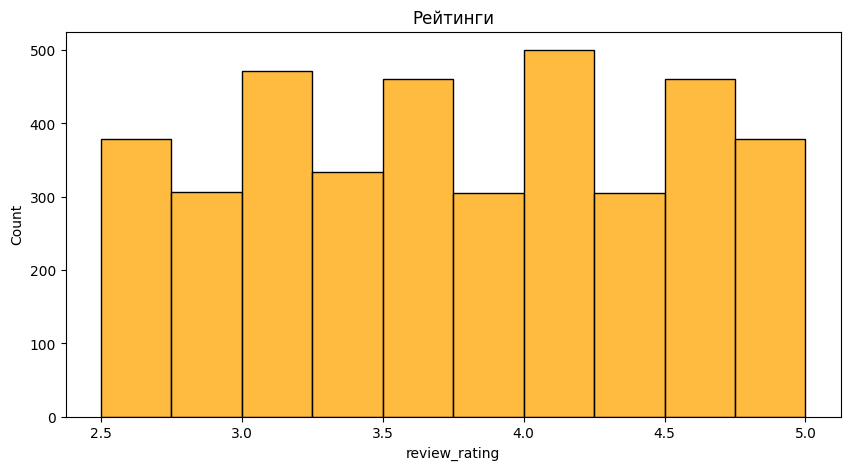

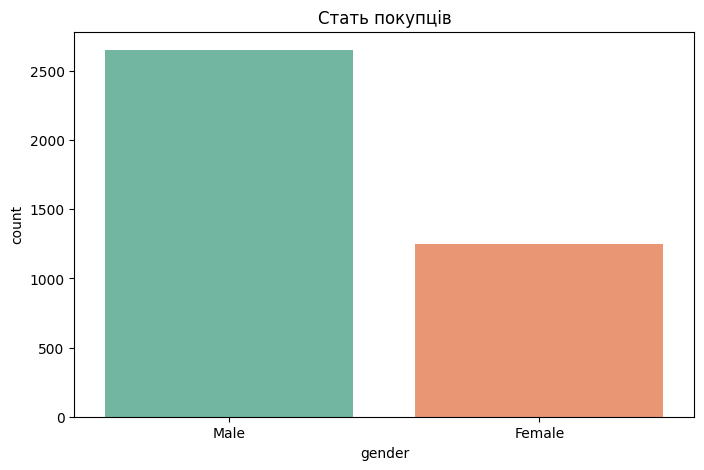

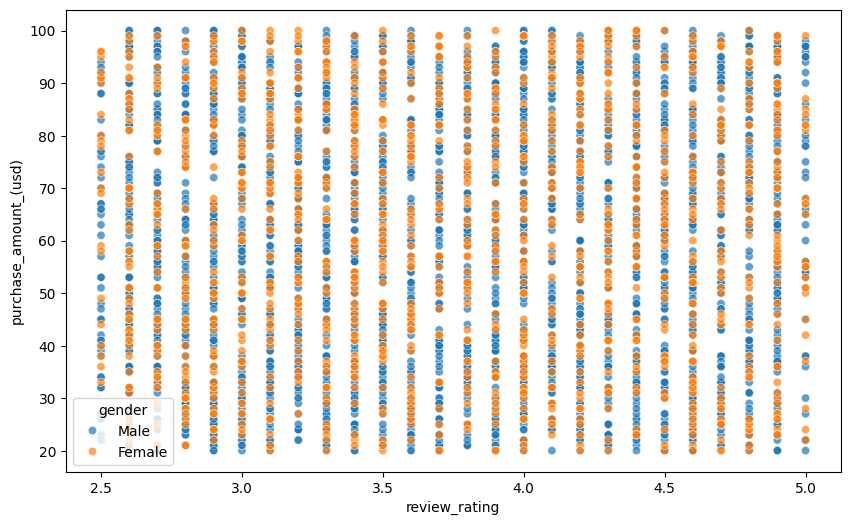

In [13]:
try:
    # грузимо шопінг дані
    df_shop = pd.read_csv('shopping_trends.csv')
    print("Розмір таблиці:", df_shop.shape)
    print("\nТипи стовпців:\n", df_shop.dtypes)

    # робимо назви колонок зручними (маленькі букви)
    df_shop.columns = df_shop.columns.str.lower().str.replace(' ', '_')
    print("\nОновлені назви стовпців:", df_shop.columns.tolist())

    # дивимось на вік покупців
    plt.figure(figsize=(10, 5))
    sns.histplot(df_shop['age'], bins=20, kde=True, color='purple')
    plt.title('Вік клієнтів')
    plt.show()

    # які товари купують частіше
    plt.figure(figsize=(14, 6))
    sns.countplot(data=df_shop, x='item_purchased', order=df_shop['item_purchased'].value_counts().index, palette='viridis', hue='item_purchased', legend=False)
    plt.xticks(rotation=90)
    plt.title('Що купують')
    plt.show()

    # чи впливає вік на суму чека
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_shop, x='age', y='purchase_amount_(usd)', alpha=0.6)
    plt.title('Вік vs Сума')
    plt.show()

    # оцінки товарів
    plt.figure(figsize=(10, 5))
    sns.histplot(df_shop['review_rating'], bins=10, color='orange')
    plt.title('Рейтинги')
    plt.show()

    # хто більше купує: чоловіки чи жінки
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df_shop, x='gender', palette='Set2', hue='gender', legend=False)
    plt.title('Стать покупців')
    plt.show()

    # зв'язок рейтингу і ціни по статях
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_shop, x='review_rating', y='purchase_amount_(usd)', hue='gender', alpha=0.7)
    plt.show()
except FileNotFoundError:
    print("Треба завантажити shopping_trends.csv")

## Завдання 3
Побудова графіків за допомогою бібліотек Altair та Plotly.

In [14]:
# графік врожайності через Altair
w_data = data.wheat()
bars = alt.Chart(w_data).mark_bar().encode(
    x=alt.X('wheat:Q', title='Врожай'),
    y=alt.Y('year:O', title='Рік', sort='-x')
)
txt = bars.mark_text(align='left', dx=3).encode(text='wheat:Q')
(bars + txt).properties(width=600).display()

# енергетика в Айові
iowa = data.iowa_electricity()
alt.Chart(iowa).mark_bar(opacity=0.7).encode(
    x='year:O',
    y='net_generation:Q',
    color='source:N'
).properties(width=600).display()

# розсіювання ірисів через Plotly
iris = px.data.iris()
px.scatter(
    iris, x="sepal_width", y="sepal_length",
    size="petal_length", color="species",
    hover_data=["petal_width"],
    title="Іриси"
).show()

alt.LayerChart(...)

alt.Chart(...)